# 05 — Model 2: PSM (Digital Twins)

1:1 nearest-neighbor matching on propensity score with a caliper.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from scipy.stats import binom
from IPython.display import display

try:
    from tqdm.notebook import tqdm
except ModuleNotFoundError:
    try:
        from tqdm.auto import tqdm
    except ModuleNotFoundError:
        def tqdm(iterable, **kwargs):
            return iterable

try:
    from helpers import load_analysis_data, prepare_model_data
    from config import FIGURE_HEIGHT
except ModuleNotFoundError:
    import sys
    from pathlib import Path
    sys.path.append(str((Path.cwd() / "notebooks").resolve()))
    from helpers import load_analysis_data, prepare_model_data
    from config import FIGURE_HEIGHT

sns.set_theme(style="whitegrid")

# Model / diagnostics configuration
NUMERIC_COVARIATES = ["age", "tenure"]
CATEGORICAL_COVARIATES = ["internet_usage", "tv_product", "mobile_product", "commune"]
PS_COVARIATES = NUMERIC_COVARIATES + CATEGORICAL_COVARIATES
PS_FORMULA = (
    "has_booster ~ age + tenure + C(internet_usage) + "
    "C(tv_product) + C(mobile_product) + C(commune)"
 )
BASE_CALIPER = 0.02
BASE_RATIO = 1
CALIPERS_TO_TEST = [0.005, 0.010, 0.020, 0.050]
RATIOS_TO_TEST = [1, 2, 3, 5]
BOOTSTRAP_ITERATIONS = 250
RANDOM_SEED = 42

df = load_analysis_data()
df_clean = prepare_model_data(df).copy()
df_clean = df_clean.reset_index(drop=False).rename(columns={"index": "_orig_index"})
print(f"Rows for PSM diagnostics: {len(df_clean):,}")

Rows for PSM diagnostics: 125,000


In [20]:
# Baseline propensity model and baseline matching
ps_model, ps_scores = fit_propensity(df_clean, formula=PS_FORMULA)
df_clean["propensity_score"] = ps_scores
baseline = run_matching(df_clean, caliper=BASE_CALIPER, ratio=BASE_RATIO, strata_col=None)

print(f"Baseline ATT (caliper={BASE_CALIPER}, ratio={BASE_RATIO}:1): {baseline['att']*100:+.2f} pp")
print(f"Matched pairs: {baseline['n_pairs']:,} | Coverage: {baseline['coverage']:.1%}")
print(f"Average match distance: {baseline['avg_distance']:.4f}")

Baseline ATT (caliper=0.02, ratio=1:1): -1.63 pp
Matched pairs: 25,000 | Coverage: 100.0%
Average match distance: 0.0000


## Diagnostic Framework (Technical Notes)

### Mathematical Definitions

- Propensity score: $e(x)=P(T=1\mid X=x)$
- ATT: $\text{ATT}=\mathbb{E}[Y(1)-Y(0)\mid T=1]$
- SMD (numeric): $\text{SMD}=\frac{\bar{x}_T-\bar{x}_C}{\sqrt{(s_T^2+s_C^2)/2}}$
- SMD (binary level indicator): same formula applied to 0/1 indicator

### How To Read Diagnostics

For each diagnostic below we report:
1. What is computed
2. Why it matters
3. What good looks like
4. What bad looks like
5. Automated pass/fail check (where possible)

Thresholds used:
- `|SMD| > 0.20` poor
- `0.10 <= |SMD| <= 0.20` acceptable
- `|SMD| < 0.10` good

## 1) Covariate Balance

- **What is computed:** SMD before/after matching for each propensity covariate and each categorical level.
- **Why it matters:** ATT is credible only when treated and control are balanced on observed confounders.
- **What good looks like:** post-match `|SMD| < 0.10` for most variables.
- **What bad looks like:** many post-match `|SMD| > 0.20`.
- **Automated check:** fail if any post-match `|SMD| > 0.20`; warn if many are in `[0.10, 0.20]`.

,variable,smd_before,smd_after,balance_grade_after
0,age,0.012589,0.054425,good
1,commune=urban,0.192049,-0.016347,good
2,commune=rural,-0.192049,0.016347,good
3,mobile_product=Low,0.170440,-0.013240,good
4,mobile_product=no_product,-0.365443,0.012684,good
5,internet_usage=Low,-0.434588,0.011383,good
6,tenure,0.055893,0.011184,good
7,tv_product=Low,-0.044835,-0.010958,good
8,mobile_product=Medium,0.197715,0.009363,good
9,internet_usage=High,0.157745,-0.007024,good


Balance check: PASS | good=16, acceptable=0, poor=0


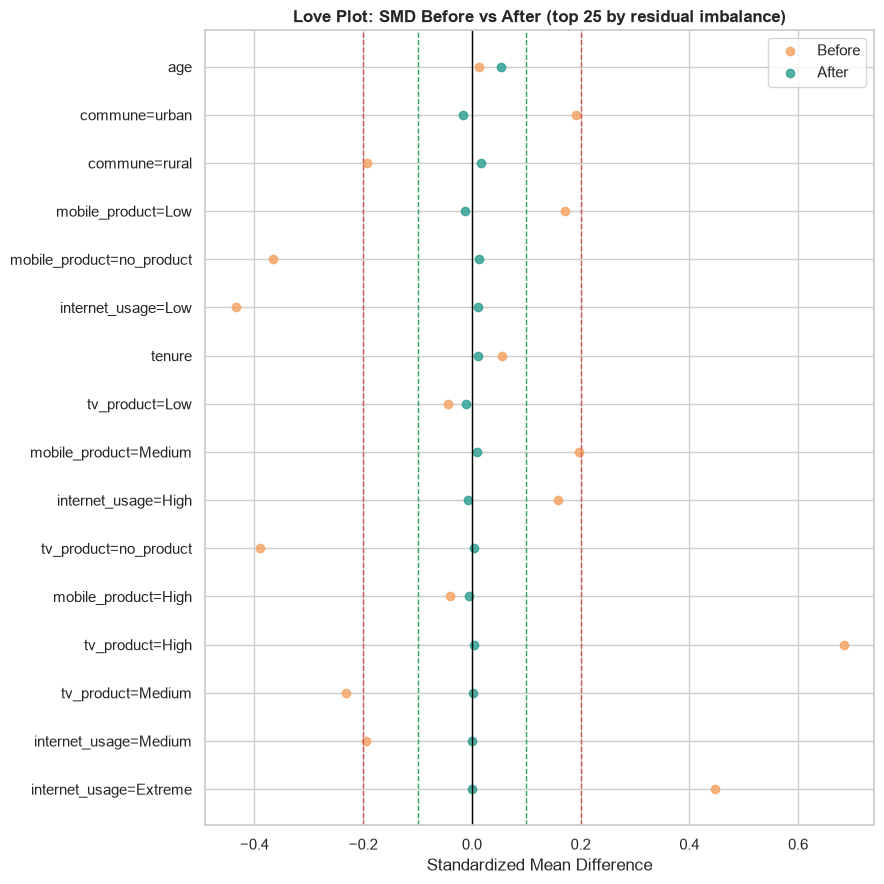

In [21]:
pairs = baseline["pairs"]
before_t = df_clean[df_clean["has_booster"] == 1].copy()
before_c = df_clean[df_clean["has_booster"] == 0].copy()
after_t = df_clean.loc[pairs["treated_orig"].to_numpy()].copy()
after_c = df_clean.loc[pairs["control_orig"].to_numpy()].copy()

balance_df = smd_table(
    before_t, before_c, after_t, after_c,
    numeric_cols=NUMERIC_COVARIATES,
    categorical_cols=CATEGORICAL_COVARIATES,
 )
display(balance_df[["variable", "smd_before", "smd_after", "balance_grade_after"]])

n_bad = int((balance_df["abs_smd_after"] > 0.20).sum())
n_acc = int(((balance_df["abs_smd_after"] >= 0.10) & (balance_df["abs_smd_after"] <= 0.20)).sum())
n_good = int((balance_df["abs_smd_after"] < 0.10).sum())
balance_pass = n_bad == 0 and n_acc <= max(2, int(0.2 * len(balance_df)))
print(f"Balance check: {'PASS' if balance_pass else 'FAIL'} | good={n_good}, acceptable={n_acc}, poor={n_bad}")

plot_df = balance_df.sort_values("abs_smd_after", ascending=True).tail(25).copy()
fig, ax = plt.subplots(figsize=(9, 9))
ax.scatter(plot_df["smd_before"], plot_df["variable"], label="Before", alpha=0.8, color="#f4a261")
ax.scatter(plot_df["smd_after"], plot_df["variable"], label="After", alpha=0.8, color="#2a9d8f")
ax.axvline(0, color="black", linewidth=1)
for thr, c in [(0.1, "#2ca25f"), (0.2, "#d9534f")]:
    ax.axvline(thr, color=c, linestyle="--", linewidth=1)
    ax.axvline(-thr, color=c, linestyle="--", linewidth=1)
ax.set_title("Love Plot: SMD Before vs After (top 25 by residual imbalance)", fontweight="bold")
ax.set_xlabel("Standardized Mean Difference")
ax.legend()
plt.tight_layout()
plt.show()

## 2) Propensity Score Overlap

- **What is computed:** treated/control propensity score distributions and common support interval.
- **Why it matters:** causal comparison requires overlap in treatment probabilities.
- **What good looks like:** broad overlap and low fraction outside support.
- **What bad looks like:** disjoint tails and large outside-support fraction.
- **Automated check:** pass if outside common support is <= 5%.

,treated_min,treated_max,control_min,control_max,support_low,support_high,outside_support_pct
0,0.012007,0.866877,0.011142,0.868388,0.012007,0.866877,0.0168


Overlap check: PASS | outside support=0.02%


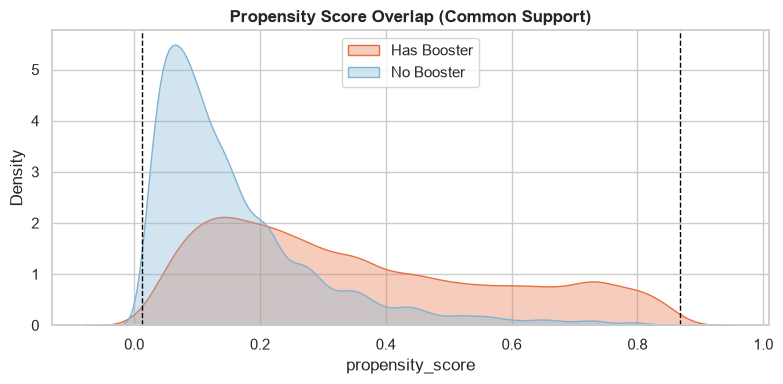

In [22]:
ov = overlap_report(df_clean)
display(pd.DataFrame([ov]))
overlap_pass = ov["outside_support_pct"] <= 5.0
print(f"Overlap check: {'PASS' if overlap_pass else 'FAIL'} | outside support={ov['outside_support_pct']:.2f}%")

treated_label = BOOSTER_LABEL_MAP[1]
control_label = BOOSTER_LABEL_MAP[0]
fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(
    data=df_clean[df_clean["has_booster"] == 1],
    x="propensity_score",
    fill=True,
    alpha=0.35,
    label=treated_label,
    color=BOOSTER_COLORS[treated_label],
    ax=ax,
 )
sns.kdeplot(
    data=df_clean[df_clean["has_booster"] == 0],
    x="propensity_score",
    fill=True,
    alpha=0.35,
    label=control_label,
    color=BOOSTER_COLORS[control_label],
    ax=ax,
 )
ax.axvline(ov["support_low"], color="black", linestyle="--", linewidth=1)
ax.axvline(ov["support_high"], color="black", linestyle="--", linewidth=1)
ax.set_title("Propensity Score Overlap (Common Support)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 3) Matching Quality

- **What is computed:** match-distance distribution and summary stats (mean/median/P90/P95/max).
- **Why it matters:** smaller distances imply closer treated-control pairs.
- **What good looks like:** low mean and P95 well below caliper.
- **What bad looks like:** many distances near caliper or heavy right tail.
- **Automated check:** pass if P95 <= caliper and mean <= caliper/2.

,mean,median,p90,p95,max
0,0.00002,4.328630e-07,0.000027,0.000133,0.003905


Distance quality check: PASS
Caliper suggestion: keep current value.


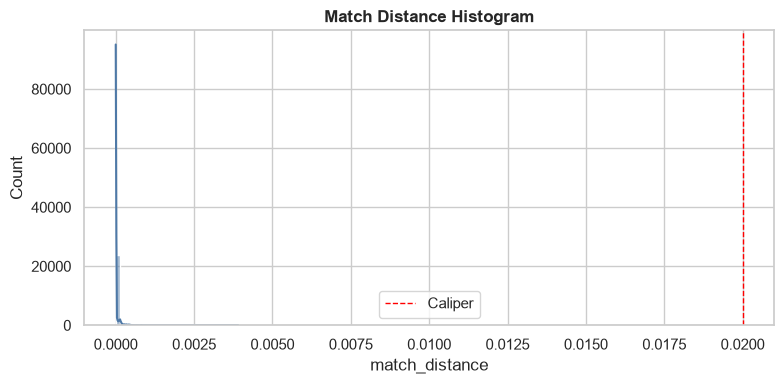

In [23]:
d = pairs["match_distance"]
dist_stats = {
    "mean": float(d.mean()),
    "median": float(d.median()),
    "p90": float(d.quantile(0.90)),
    "p95": float(d.quantile(0.95)),
    "max": float(d.max()),
}
display(pd.DataFrame([dist_stats]))
quality_pass = dist_stats["p95"] <= BASE_CALIPER and dist_stats["mean"] <= BASE_CALIPER / 2
print(f"Distance quality check: {'PASS' if quality_pass else 'FAIL'}")
if dist_stats["p95"] >= BASE_CALIPER * 0.95:
    print("Caliper suggestion: decrease (many retained pairs are near threshold).")
elif baseline["coverage"] < 0.70:
    print("Caliper suggestion: increase (coverage is low).")
else:
    print("Caliper suggestion: keep current value.")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(d, bins=30, kde=True, ax=ax, color="#4e79a7")
ax.axvline(BASE_CALIPER, color="red", linestyle="--", linewidth=1, label="Caliper")
ax.set_title("Match Distance Histogram", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 4) Control Reuse

- **What is computed:** matched pairs, unique controls, average reuse, maximum reuse.
- **Why it matters:** replacement can reduce bias, but excessive reuse increases variance and leverage.
- **What good looks like:** low average reuse and moderate max reuse.
- **What bad looks like:** heavy reuse concentration in a few controls.
- **Automated check:** pass if `max_reuse <= 20` and `average_reuse <= 3`.

,matched_pairs,unique_controls,average_reuse,max_reuse
0,25000,16435,1.521144,23


Reuse check: FAIL


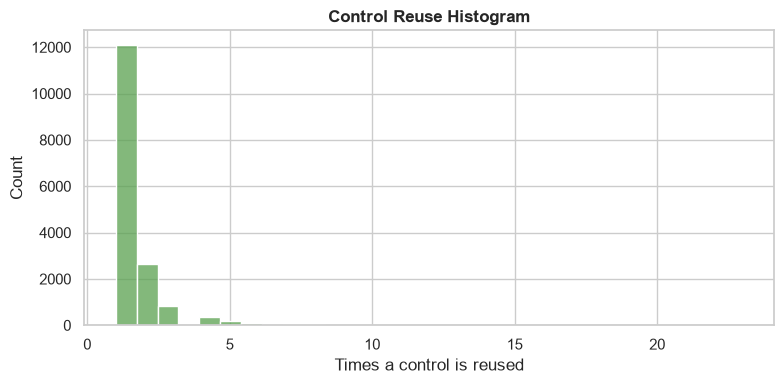

In [24]:
reuse = pairs["control_orig"].value_counts()
reuse_stats = {
    "matched_pairs": int(len(pairs)),
    "unique_controls": int(reuse.shape[0]),
    "average_reuse": float(reuse.mean()),
    "max_reuse": int(reuse.max()),
}
display(pd.DataFrame([reuse_stats]))
reuse_pass = reuse_stats["max_reuse"] <= 20 and reuse_stats["average_reuse"] <= 3
print(f"Reuse check: {'PASS' if reuse_pass else 'FAIL'}")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(reuse, bins=30, ax=ax, color="#59a14f")
ax.set_title("Control Reuse Histogram", fontweight="bold")
ax.set_xlabel("Times a control is reused")
plt.tight_layout()
plt.show()

## 5) Caliper Sensitivity

- **What is computed:** ATT, matched pairs, coverage, and average match distance across calipers.
- **Why it matters:** caliper controls bias-variance tradeoff via match strictness.
- **What good looks like:** ATT stable while quality/coverage remain acceptable.
- **What bad looks like:** ATT changes strongly with small caliper changes.
- **Automated check:** pass if ATT std across tested calipers is <= 1 pp.

In [25]:
rows = []
for c in CALIPERS_TO_TEST:
    res = run_matching(df_clean, caliper=c, ratio=1, strata_col=None)
    rows.append({
        "caliper": c,
        "matched_pairs": res["n_pairs"],
        "coverage": res["coverage"],
        "att": res["att"],
        "avg_match_distance": res["avg_distance"],
    })
caliper_df = pd.DataFrame(rows)
display(caliper_df)
caliper_pass = caliper_df["att"].std() <= 0.01
print(f"Caliper sensitivity check: {'PASS' if caliper_pass else 'FAIL'}")

,caliper,matched_pairs,coverage,att,avg_match_distance
0,0.005,25000,1.0,-0.01632,0.00002
1,0.010,25000,1.0,-0.01632,0.00002
2,0.020,25000,1.0,-0.01632,0.00002
3,0.050,25000,1.0,-0.01632,0.00002


Caliper sensitivity check: PASS


## 6) Matching Ratio Sensitivity

- **What is computed:** ATT and matched sample size for 1:k nearest-neighbor matching.
- **Why it matters:** higher k may reduce variance but can increase bias.
- **What good looks like:** ATT stable as k changes.
- **What bad looks like:** large ATT drift as k increases.
- **Automated check:** pass if ATT std across tested ratios is <= 1 pp.

In [26]:
ratio_rows = []
for r in RATIOS_TO_TEST:
    res = run_matching(df_clean, caliper=BASE_CALIPER, ratio=r, strata_col=None)
    ratio_rows.append({
        "ratio": f"1:{r}",
        "att": res["att"],
        "matched_treated": res["matched_treated"],
        "matched_pairs": res["n_pairs"],
        "coverage": res["coverage"],
    })
ratio_df = pd.DataFrame(ratio_rows)
display(ratio_df)
ratio_pass = ratio_df["att"].std() <= 0.01
print(f"Ratio sensitivity check: {'PASS' if ratio_pass else 'FAIL'}")

,ratio,att,matched_treated,matched_pairs,coverage
0,1:1,-0.016320,25000,25000,1.0
1,1:2,-0.018240,25000,50000,1.0
2,1:3,-0.018267,25000,75000,1.0
3,1:5,-0.017592,25000,125000,1.0


Ratio sensitivity check: PASS


## 7) Within-Tier Matching

- **What is computed:** ATT from global PSM vs exact-within-tier matching on `internet_usage`.
- **Why it matters:** exact matching on strong effect modifiers can reduce residual heterogeneity bias.
- **What good looks like:** similar ATT between global and within-tier matching.
- **What bad looks like:** large divergence indicating sensitivity to mixing across tiers.
- **Automated check:** pass if `|ATT_within_tier - ATT_global| <= 1 pp`.

In [27]:
global_att = baseline["att"]
tiered_res = run_matching(df_clean, caliper=BASE_CALIPER, ratio=1, strata_col="internet_usage")
tiered_att = tiered_res["att"]
tier_compare = pd.DataFrame([{
    "method": "Global PSM", "att": global_att, "matched_pairs": baseline["n_pairs"], "coverage": baseline["coverage"]
}, {
    "method": "Within-tier PSM", "att": tiered_att, "matched_pairs": tiered_res["n_pairs"], "coverage": tiered_res["coverage"]
}])
display(tier_compare)
tier_pass = abs(tiered_att - global_att) <= 0.01
print(f"Within-tier consistency check: {'PASS' if tier_pass else 'FAIL'}")

,method,att,matched_pairs,coverage
0,Global PSM,-0.01632,25000,1.0
1,Within-tier PSM,-0.01772,25000,1.0


Within-tier consistency check: PASS


## 8) Propensity Model Diagnostics

- **What is computed:** logistic coefficients, odds ratios, ROC AUC, calibration curve, Brier score, and score histogram.
- **Why it matters:** PS model predicts treatment assignment, but balancing covariates remains the target objective.
- **What good looks like:** interpretable selectivity and no severe calibration pathology.
- **What bad looks like:** extreme separation with poor overlap or severe miscalibration.
- **Automated check:** not a strict pass/fail for model fit itself; use overlap and balance checks as primary criteria.

AUC interpretation bands:
- Low: < 0.60
- Moderate: 0.60 to < 0.75
- High: >= 0.75

,Coef.,Std.Err.,P>|z|,odds_ratio
Intercept,-1.538707,0.038143,0.000000e+00,0.214659
C(internet_usage)[T.Medium],0.672411,0.026316,5.246144e-144,1.958955
C(internet_usage)[T.High],1.225787,0.025773,0.000000e+00,3.406847
C(internet_usage)[T.Extreme],1.883599,0.027102,0.000000e+00,6.577136
C(tv_product)[T.Low],-1.604556,0.021560,0.000000e+00,0.200979
C(tv_product)[T.Medium],-1.944248,0.023102,0.000000e+00,0.143095
C(tv_product)[T.no_product],-2.304280,0.024873,0.000000e+00,0.099831
C(mobile_product)[T.Low],0.333730,0.020567,3.282575e-59,1.396166
C(mobile_product)[T.Medium],0.418502,0.020950,8.864043e-89,1.519683
C(mobile_product)[T.no_product],-0.757957,0.025475,1.594961e-194,0.468623


ROC AUC: 0.779
Brier score: 0.1286
AUC interpretation: high selectivity.


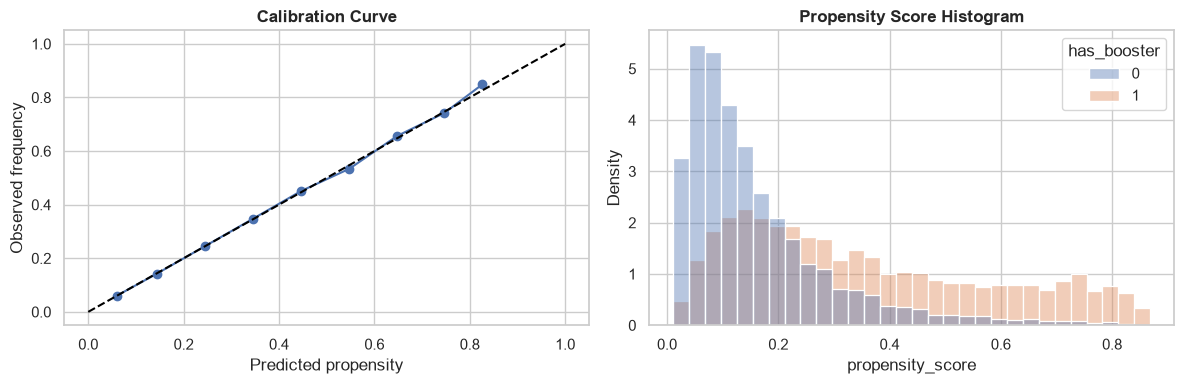

In [28]:
coef_df = ps_model.summary2().tables[1].copy()
coef_df["odds_ratio"] = np.exp(coef_df["Coef."])
display(coef_df[["Coef.", "Std.Err.", "P>|z|", "odds_ratio"]])

auc = roc_auc_score(df_clean["has_booster"], df_clean["propensity_score"])
brier = brier_score_loss(df_clean["has_booster"], df_clean["propensity_score"])
print(f"ROC AUC: {auc:.3f}")
print(f"Brier score: {brier:.4f}")
if auc < 0.60:
    print("AUC interpretation: low selectivity.")
elif auc < 0.75:
    print("AUC interpretation: moderate selectivity.")
else:
    print("AUC interpretation: high selectivity.")

prob_true, prob_pred = calibration_curve(df_clean["has_booster"], df_clean["propensity_score"], n_bins=10)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(prob_pred, prob_true, marker="o")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="black")
axes[0].set_title("Calibration Curve", fontweight="bold")
axes[0].set_xlabel("Predicted propensity")
axes[0].set_ylabel("Observed frequency")
sns.histplot(data=df_clean, x="propensity_score", hue="has_booster", bins=30, stat="density", common_norm=False, alpha=0.4, ax=axes[1])
axes[1].set_title("Propensity Score Histogram", fontweight="bold")
plt.tight_layout()
plt.show()

## 9) Bootstrap ATT Confidence Interval

- **What is computed:** bootstrap ATT with re-sampling, PS refit, rematching, and ATT recomputation each replication.
- **Why it matters:** accounts for uncertainty from both propensity estimation and matching procedure.
- **What good looks like:** stable CI and sufficient successful replications.
- **What bad looks like:** unstable CI, many failed replications, or sign-flip around 0.
- **Automated check:** pass if 95% CI excludes 0.

Bootstrap formulas used:
- Point estimate: $\widehat{\mathrm{ATT}} = \frac{1}{n_T}\sum_{i:T_i=1}\left(Y_i-\widehat{Y}_i(0)\right)$
- Bootstrap sample estimates: $\widehat{\mathrm{ATT}}^{(b)},\ b=1,\ldots,B$
- Bootstrap standard error: $\widehat{SE}_{boot}=\sqrt{\frac{1}{B-1}\sum_{b=1}^{B}(\widehat{\mathrm{ATT}}^{(b)}-\overline{\widehat{\mathrm{ATT}}})^2}$
- Percentile 95% CI: $\left[Q_{0.025}(\widehat{\mathrm{ATT}}^{(b)}),\ Q_{0.975}(\widehat{\mathrm{ATT}}^{(b)})\right]$

In [30]:
rng = np.random.default_rng(RANDOM_SEED)
boot_att = []
for _ in tqdm(range(BOOTSTRAP_ITERATIONS), total=BOOTSTRAP_ITERATIONS, desc="Bootstrap ATT", dynamic_ncols=True):
    sample_idx = rng.integers(0, len(df_clean), len(df_clean))
    bdf = df_clean.drop(columns=["_orig_index"]).iloc[sample_idx].copy().reset_index(drop=True)
    bdf["_orig_index"] = np.arange(len(bdf))
    try:
        _, b_ps = fit_propensity(bdf, formula=PS_FORMULA)
        bdf["propensity_score"] = b_ps
        b_res = run_matching(bdf, caliper=BASE_CALIPER, ratio=1, strata_col=None)
        if np.isfinite(b_res["att"]):
            boot_att.append(b_res["att"])
    except Exception:
        continue

boot_att = np.array(boot_att)
if len(boot_att) == 0:
    raise RuntimeError("Bootstrap failed: no valid replications.")
boot_se = float(boot_att.std(ddof=1))
ci_low, ci_high = np.quantile(boot_att, [0.025, 0.975])
boot_summary = pd.DataFrame([{
    "att": baseline["att"],
    "bootstrap_se": boot_se,
    "ci_low_95": float(ci_low),
    "ci_high_95": float(ci_high),
    "successful_replications": int(len(boot_att)),
}])
display(boot_summary)
boot_pass = not (ci_low <= 0 <= ci_high)
print(f"Bootstrap CI check: {'PASS' if boot_pass else 'FAIL'}")

Bootstrap ATT:   0%|          | 0/250 [00:00<?, ?it/s]

,att,bootstrap_se,ci_low_95,ci_high_95,successful_replications
0,-0.01632,0.004396,-0.028271,-0.010532,250


Bootstrap CI check: PASS


## 10) Rosenbaum Sensitivity Analysis (Approximate)

- **What is computed:** upper-bound p-value curve over hidden-bias multiplier $\Gamma$ using discordant matched pairs.
- **Why it matters:** quantifies how much unobserved confounding is needed to overturn significance.
- **What good looks like:** significance robust to larger $\Gamma$.
- **What bad looks like:** significance lost near $\Gamma=1$ (fragile to mild hidden bias).
- **Automated check:** pass if critical $\Gamma$ (where p-value crosses 0.05) is >= 1.5.

,gamma,upper_p_value
0,1.00,4.199623e-08
1,1.05,2.277250e-04
2,1.10,4.091033e-02
3,1.15,4.782245e-01
4,1.20,9.403380e-01
5,1.25,9.990395e-01
6,1.30,9.999977e-01
7,1.35,1.000000e+00
8,1.40,1.000000e+00
9,1.45,1.000000e+00


Result: significance is lost around Gamma=1.15.
Rosenbaum robustness check: FAIL


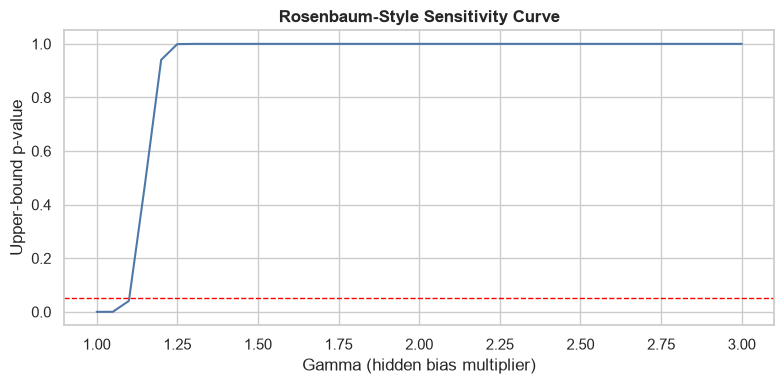

In [ ]:
disc = pairs[pairs["treated_outcome"] != pairs["control_outcome"]].copy()
n_disc = len(disc)
better = int(((disc["treated_outcome"] == 0) & (disc["control_outcome"] == 1)).sum())
if n_disc == 0:
    print("No discordant pairs; Rosenbaum-style paired test is uninformative.")
else:
    gamma_grid = np.arange(1.0, 3.05, 0.05)
    upper_p = []
    for gamma in gamma_grid:
        p_upper = gamma / (1 + gamma)
        pval = binom.sf(better - 1, n_disc, p_upper)
        upper_p.append(float(pval))
    sens_df = pd.DataFrame({"gamma": gamma_grid, "upper_p_value": upper_p})
    display(sens_df.head(10))
    crossing = sens_df[sens_df["upper_p_value"] >= 0.05]
    critical_gamma = float(crossing["gamma"].iloc[0]) if len(crossing) > 0 else np.nan
    if np.isnan(critical_gamma):
        print("Result: effect remains significant up to Gamma=3.0.")
    else:
        print(f"Result: significance is lost around Gamma={critical_gamma:.2f}.")
    rosen_pass = np.isnan(critical_gamma) or critical_gamma >= 1.5
    print(f"Rosenbaum robustness check: {'PASS' if rosen_pass else 'FAIL'}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(sens_df["gamma"], sens_df["upper_p_value"], color="#4e79a7")
    ax.axhline(0.05, color="red", linestyle="--", linewidth=1)
    ax.set_title("Rosenbaum-Style Sensitivity Curve", fontweight="bold")
    ax.set_xlabel("Gamma (hidden bias multiplier)")
    ax.set_ylabel("Upper-bound p-value")
    plt.tight_layout()
    plt.show()